In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 17.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Leitura do arquivo ────────────────────────────────────────────────────────
CSV_FILE = "tournaments/2026-03-10_14-03-30_42141479_games.csv"
df = pd.read_csv(CSV_FILE)

# índice = número da partida (1-based)
df.index = range(1, len(df) + 1)

print(f"Arquivo: {CSV_FILE}")
print(f"Partidas: {len(df)}")
print(df[['white_player','black_player','result','white_avg_depth','black_avg_depth','white_avg_nodes','black_avg_nodes']].to_string())


FileNotFoundError: [Errno 2] No such file or directory: 'tournaments/2026-03-10_14-03-30_42141479_games.csv'

In [ ]:
# ── Gráfico 1: Profundidade média por partida (por agente) ───────────────────
# Como os lados alternam a cada partida, precisamos mapear as métricas
# pelo nome do agente, não pela cor.


fig, ax = plt.subplots(figsize=(10, 4))

for agent, color, marker in zip(agents, colors, markers):
    depths = []
    for _, row in df.iterrows():
        if row['white_player'] == agent:
            depths.append(row['white_avg_depth'])
        else:
            depths.append(row['black_avg_depth'])
    ax.plot(df.index, depths, f'{marker}-', color=color, label=agent)

ax.set_xlabel('Partida')
ax.set_ylabel('Profundidade média alcançada')
ax.set_title('Profundidade média por partida (por agente)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tournaments/depth_per_game.png', dpi=150)
plt.show()
print('Salvo: tournaments/depth_per_game.png')


NameError: name 'df' is not defined

In [6]:
# ── Gráfico 2: Nós explorados médios por partida (por agente) ────────────────
agents = sorted(df['white_player'].unique())
colors = ['steelblue', 'tomato']
markers = ['o', 's']
fig, ax = plt.subplots(figsize=(10, 4))

for agent, color, marker in zip(agents, colors, markers):
    nodes = []
    for _, row in df.iterrows():
        if row['white_player'] == agent:
            nodes.append(row['white_avg_nodes'])
        else:
            nodes.append(row['black_avg_nodes'])
    ax.plot(df.index, nodes, f'{marker}-', color=color, label=agent)

ax.set_xlabel('Partida')
ax.set_ylabel('Nós explorados (média por jogada)')
ax.set_title('Nós explorados por partida (por agente)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tournaments/nodes_per_game.png', dpi=150)
plt.show()
print('Salvo: tournaments/nodes_per_game.png')


NameError: name 'df' is not defined

Arquivos encontrados: 3

Médias por heurística:
               prof_média  nós_médios
agent                                
h1-Material          15.0    58,584.9
h2-Posicional        13.4    52,993.6
h3-Completa          14.9    35,131.8



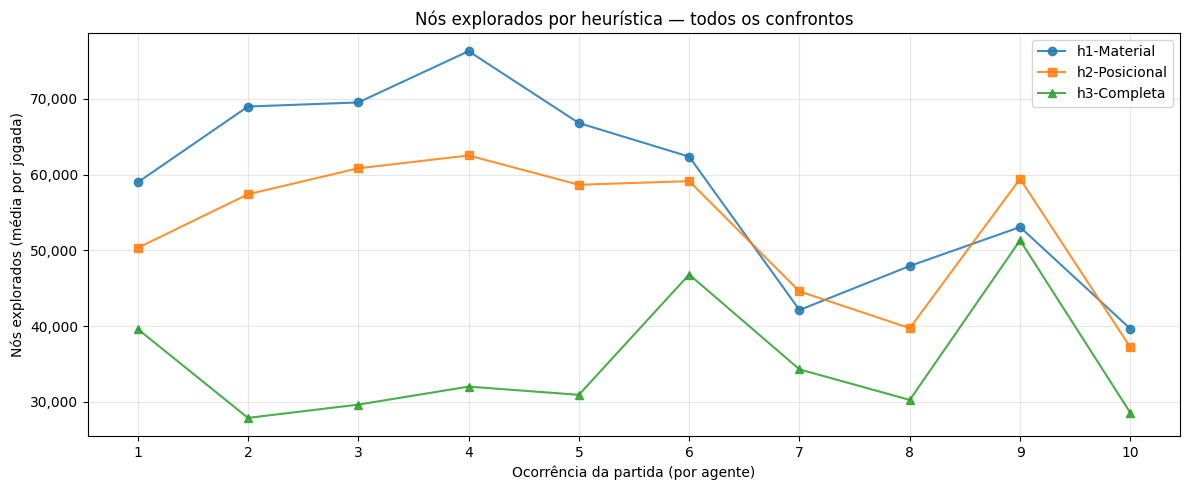

Salvo: tournaments/all_nodes_per_heuristic.png


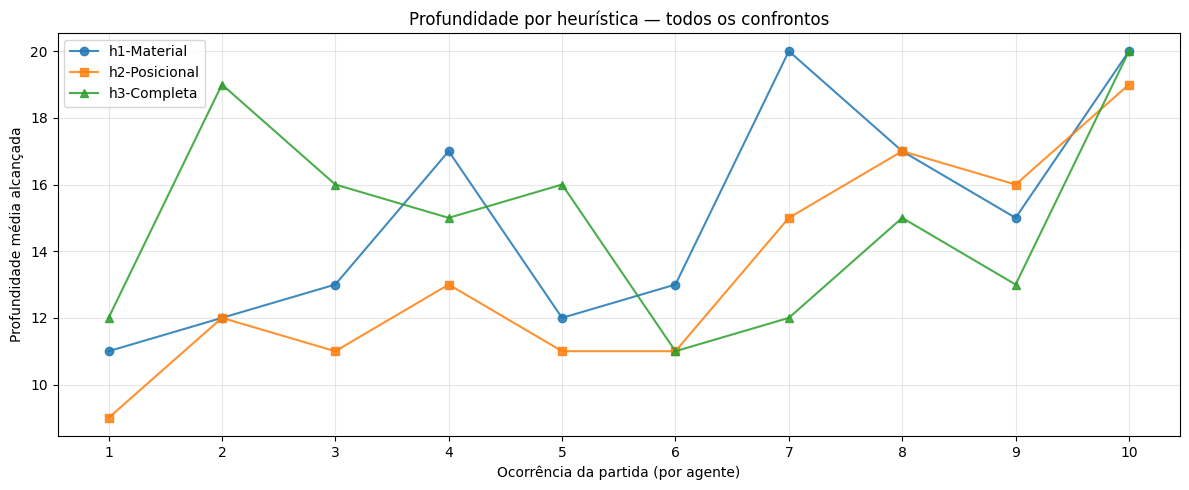

Salvo: tournaments/all_depth_per_heuristic.png


In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Leitura de todos os arquivos *_games.csv ──────────────────────────────────
files = sorted(glob.glob("tournaments/*_games.csv"))
print(f"Arquivos encontrados: {len(files)}")

# Constrói um DataFrame longo: uma linha por (agente, partida)
records = []
for path in files:
    df_f = pd.read_csv(path)
    for _, row in df_f.iterrows():
        for side in ['white', 'black']:
            records.append({
                'agent':   row[f'{side}_player'],
                'nodes':   row[f'{side}_avg_nodes'],
                'depth':   row[f'{side}_avg_depth'],
                'file':    path,
                'game_id': row['game_id'],
            })

long_df = pd.DataFrame(records)

# ── Resumo: média de profundidade e nós por agente ────────────────────────────
summary = (
    long_df.groupby('agent')[['depth', 'nodes']]
    .mean()
    .rename(columns={'depth': 'prof_média', 'nodes': 'nós_médios'})
    .sort_index()
)
print("\nMédias por heurística:")
print(summary.to_string(float_format=lambda x: f'{x:,.1f}'))
print()

# Ordena agentes e atribui cor/marcador fixo por heurística
palette = {
    'h1-Material':      ('tab:blue',   'o'),
    'h2-Posicional':    ('tab:orange', 's'),
    'h3-Completa':      ('tab:green',  '^'),
    'h4-Conectividade': ('tab:red',    'D'),
}

agents_found = sorted(long_df['agent'].unique())

# ── Gráfico 1: Nós explorados por heurística (todas as partidas) ─────────────
fig, ax = plt.subplots(figsize=(12, 5))

for agent in agents_found:
    sub = long_df[long_df['agent'] == agent].reset_index(drop=True)
    color, marker = palette.get(agent, ('grey', 'x'))
    ax.plot(sub.index + 1, sub['nodes'], f'{marker}-',
            color=color, label=agent, alpha=0.85)

ax.set_xlabel('Ocorrência da partida (por agente)')
ax.set_ylabel('Nós explorados (média por jogada)')
ax.set_title('Nós explorados por heurística — todos os confrontos')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tournaments/all_nodes_per_heuristic.png', dpi=150)
plt.show()
print('Salvo: tournaments/all_nodes_per_heuristic.png')

# ── Gráfico 2: Profundidade por heurística (todas as partidas) ───────────────
fig, ax = plt.subplots(figsize=(12, 5))

for agent in agents_found:
    sub = long_df[long_df['agent'] == agent].reset_index(drop=True)
    color, marker = palette.get(agent, ('grey', 'x'))
    ax.plot(sub.index + 1, sub['depth'], f'{marker}-',
            color=color, label=agent, alpha=0.85)

ax.set_xlabel('Ocorrência da partida (por agente)')
ax.set_ylabel('Profundidade média alcançada')
ax.set_title('Profundidade por heurística — todos os confrontos')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tournaments/all_depth_per_heuristic.png', dpi=150)
plt.show()
print('Salvo: tournaments/all_depth_per_heuristic.png')
